=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=heap with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '5', '--table-type', 'heap']
-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 150000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 750
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 750
idx:   4, tx_id:   4, t

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,32.919385,150000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,heap,32.945277,150000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,heap,33.363059,150000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,heap,0.000000,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,heap,0.000000,NaN,1.0,NaN,NaN
6,2,2,Update,No Repair,heap,0.297656,750.0,NaN,NaN,NaN
7,2,2,Update,Read Repair,heap,0.295155,750.0,NaN,NaN,NaN
8,2,2,Update,Write Repair,heap,2.767637,750.0,NaN,NaN,NaN
9,3,3,Update,No Repair,heap,0.171324,750.0,NaN,NaN,NaN


duration_max: 66.84689


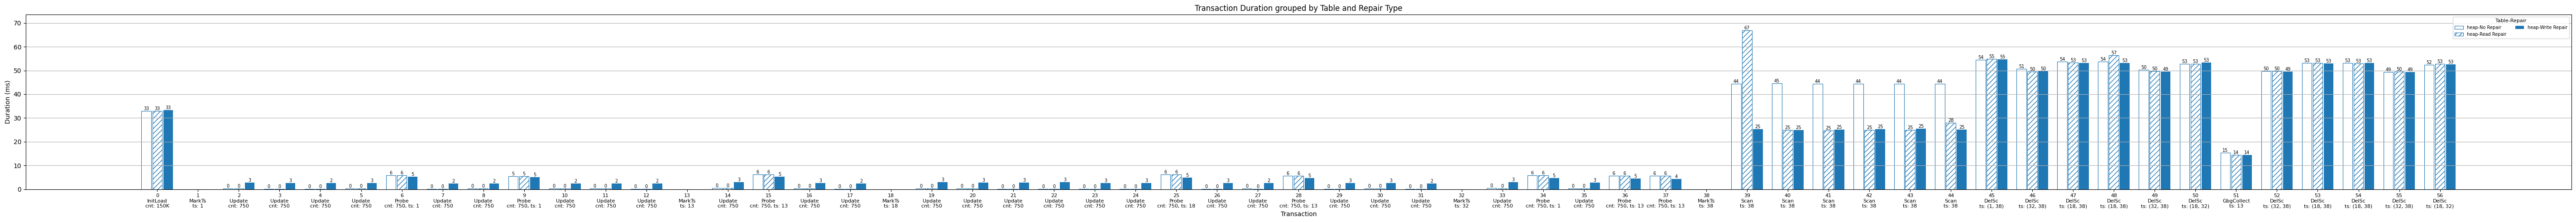

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "5" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
from bench_script_functions import run_and_collect
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# DELTA TRADEOFF

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '35', '--op-ratio', '0.005', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 5250
idx:   4, tx_id:

,table_type,repair_type,tx_type,duration_ms
14,chain,Write Repair,DeltaScan,13973.934706
15,chain,Write Repair,GbgCollect,1.159850
16,chain,Write Repair,InitLoad,738.888296
17,chain,Write Repair,MarkTs,0.000000
18,chain,Write Repair,Probe,3540.234696
19,chain,Write Repair,Scan,3469.739168
20,chain,Write Repair,Update,2434.394363


,table_type,repair_type,tx_type,duration_ms
21,heap,No Repair,DeltaScan,16237.221829
22,heap,No Repair,GbgCollect,334.622165
23,heap,No Repair,InitLoad,769.893542
24,heap,No Repair,MarkTs,0.000000
25,heap,No Repair,Probe,5624.285697
26,heap,No Repair,Scan,6451.238353
27,heap,No Repair,Update,108.439400


,table_type,repair_type,tx_type,duration_ms
28,heap,Read Repair,DeltaScan,15814.509962
29,heap,Read Repair,GbgCollect,328.483786
30,heap,Read Repair,InitLoad,773.795713
31,heap,Read Repair,MarkTs,0.000000
32,heap,Read Repair,Probe,5602.727842
33,heap,Read Repair,Scan,4581.955679
34,heap,Read Repair,Update,107.805969


,table_type,repair_type,tx_type,duration_ms
35,heap,Write Repair,DeltaScan,15896.485265
36,heap,Write Repair,GbgCollect,316.437041
37,heap,Write Repair,InitLoad,770.352803
38,heap,Write Repair,MarkTs,0.000000
39,heap,Write Repair,Probe,5147.985973
40,heap,Write Repair,Scan,3540.771093
41,heap,Write Repair,Update,2501.375609


...

,table_type,repair_type,tx_type,duration_ms
56,naive,Write Repair,DeltaScan,32107.637205
57,naive,Write Repair,GbgCollect,0.000000
58,naive,Write Repair,InitLoad,868.046592
59,naive,Write Repair,MarkTs,4529.082110
60,naive,Write Repair,Probe,2028.188846
61,naive,Write Repair,Scan,3922.394502
62,naive,Write Repair,Update,877.660849


,table_type,repair_type,tx_type,duration_ms
63,par,No Repair,DeltaScan,2840.600774
64,par,No Repair,GbgCollect,592.820503
65,par,No Repair,InitLoad,797.344488
66,par,No Repair,MarkTs,37.530019
67,par,No Repair,Probe,6725.549736
68,par,No Repair,Scan,9208.357111
69,par,No Repair,Update,836.471453


,table_type,repair_type,tx_type,duration_ms
70,par,Read Repair,DeltaScan,2865.721879
71,par,Read Repair,GbgCollect,414.234555
72,par,Read Repair,InitLoad,802.385401
73,par,Read Repair,MarkTs,37.495836
74,par,Read Repair,Probe,6732.408874
75,par,Read Repair,Scan,5620.575242
76,par,Read Repair,Update,853.786406


,table_type,repair_type,tx_type,duration_ms
77,par,Write Repair,DeltaScan,2841.301221
78,par,Write Repair,GbgCollect,434.508742
79,par,Write Repair,InitLoad,825.275878
80,par,Write Repair,MarkTs,43.836606
81,par,Write Repair,Probe,5631.891811
82,par,Write Repair,Scan,4827.664645
83,par,Write Repair,Update,5123.412123


,table_type,repair_type,tx_type,duration_ms_first,duration_ms_last,delta,pct_contribution
0,chain,No Repair,DeltaScan,14082.801812,16071.919433,1989.117621,20.335886
1,chain,No Repair,GbgCollect,1.115682,8.407598,7.291916,0.074549
2,chain,No Repair,InitLoad,766.883269,762.209694,-4.673575,-0.047781
3,chain,No Repair,MarkTs,0.000000,0.000000,0.000000,0.000000
4,chain,No Repair,Probe,3476.885126,8301.241014,4824.355888,49.322146
5,chain,No Repair,Scan,3520.215665,4241.505176,721.289511,7.374155
6,chain,No Repair,Update,2441.599306,4685.535771,2243.936465,22.941044
7,chain,Read Repair,DeltaScan,14071.343567,15891.081738,1819.738171,19.339103
8,chain,Read Repair,GbgCollect,1.162875,8.376851,7.213976,0.076666
9,chain,Read Repair,InitLoad,747.693298,738.195204,-9.498094,-0.100940


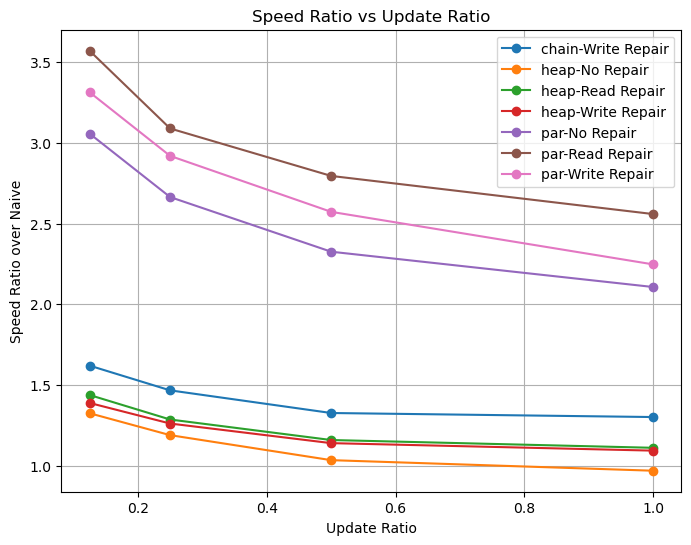

In [8]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"]
UPDATE_RATIOS = ["0.005", "0.01", "0.02", "0.04"]

from bench_script_functions import run_and_collect
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
update_count = 0
for update_ratio in UPDATE_RATIOS:
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--op-ratio", update_ratio]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    update_count = (
        df[df["tx_type"] == "Update"]
        .groupby(["table_type", "repair_type"])
        .size()
        .iloc[0]  # 只取一个，因为都一样
    )
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', update_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)
assert(len(df_list) > 1)
df_first = df_list[0]
df_last = df_list[-1]
merged = pd.merge(
    df_first,
    df_last,
    on=["table_type", "repair_type", "tx_type"],
    how="inner",
    suffixes=("_first", "_last")
)
# 增长量
merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# 总增长（每组 table_type + repair_type）
group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# 每个 tx_type 对增长的百分比贡献
merged["pct_contribution"] = merged["delta"] / group_total * 100
display(merged)

# print(f"update_count : {update_count}")


df_ratio['update_ratio'] = df_ratio['update_ratio'].astype(float) * update_count
# display(df_ratio)
df = df_ratio.sort_values(by="update_ratio")

# 按 (table_type, repair_type) 分组画图
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["update_ratio"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("Update Ratio")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs Update Ratio")
plt.legend()
plt.grid(True)
plt.show()



# Space Statistics

In [ ]:
# import subprocess
# from pathlib import Path
# import pandas as pd
# import matplotlib.pyplot as plt
# import re

# # ----------------------------------------
# # Build the Rust binary
# # ----------------------------------------
# print("=== Building Rust binary in release mode ===")
# build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
# result = subprocess.run(build_cmd, capture_output=True, text=True)
# if result.returncode != 0:
#     print("[ERROR] cargo build failed.\n", result.stderr)
#     raise SystemExit(1)
# print("Cargo build completed successfully.\n")


# BASE_ARGS = [
#     "--op-ratio", "0.01",  # update ratio, % of base table
#     "--txn-count", "25",  
#     "--scan-count", "6",  # delta scan count
#     "--warehouse-count", "33" # linear to base table size
# ]
# REPEAT=1
# BIN = Path("../../../target/release/htap_wkld")
# TABLE_TYPES = [ "naive", "heap", "par", "chain"]

# from bench_script_functions import run_and_collect

# df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# # Display the resulting DataFrame
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# display(df)

# def plot_nested_space(df):
#     for col in ["total_space", "all_versions_space", "valid_space"]:
#         df[col] = pd.to_numeric(df[col], errors="coerce")

#     df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
#     df["valid_ratio"] = df["valid_space"] / df["total_space"]

#     fig, ax = plt.subplots(figsize=(8,6))
#     bar_width = 0.5

#     ax.bar(df["table_type"], df["total_space"], 
#            color="lightgray", width=bar_width, label="total_space")
#     ax.bar(df["table_type"], df["all_versions_space"], 
#            color="skyblue", width=bar_width*0.7, label="all_versions_space")
#     ax.bar(df["table_type"], df["valid_space"], 
#            color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

#     for i, row in df.iterrows():
#         total_mb = row["total_space"] / 1e6
#         all_versions_mb = row["all_versions_space"] / 1e6
#         valid_mb = row["valid_space"] / 1e6

#         ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")
#         ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")
#         ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")

#         ax.text(i + 0.2, row["all_versions_space"] * 1.02,
#                 f"{row['all_versions_ratio']:.1%}", 
#                 ha="center", va="bottom", fontsize=9, color="blue")
#         ax.text(i + 0.2, row["valid_space"] * 1.02,
#                 f"{row['valid_ratio']:.1%}", 
#                 ha="center", va="bottom", fontsize=9, color="darkblue")

#     ax.set_ylabel("Space (bytes)")
#     max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
#     ax.set_ylim(0, max_value * 1.15)
#     ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
#     ax.legend()
#     plt.tight_layout()
#     plt.show()


# plot_nested_space(df)



# Stacked Bar Chart -- analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '4', '--analytical-ratio', '0.9', '--scan-count', '9', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.9
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 9

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 120000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:      Probe, Probe count: 600 at read_ts: 1
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Pro

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,1402.849821
1,chain,Write Repair,GbgCollect,0.073665
2,chain,Write Repair,InitLoad,82.950005
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,127.821841
5,chain,Write Repair,Scan,672.725479
6,chain,Write Repair,Update,29.521084
7,heap,No Repair,DelSc,1560.792404
8,heap,No Repair,GbgCollect,28.129563
9,heap,No Repair,InitLoad,82.716185


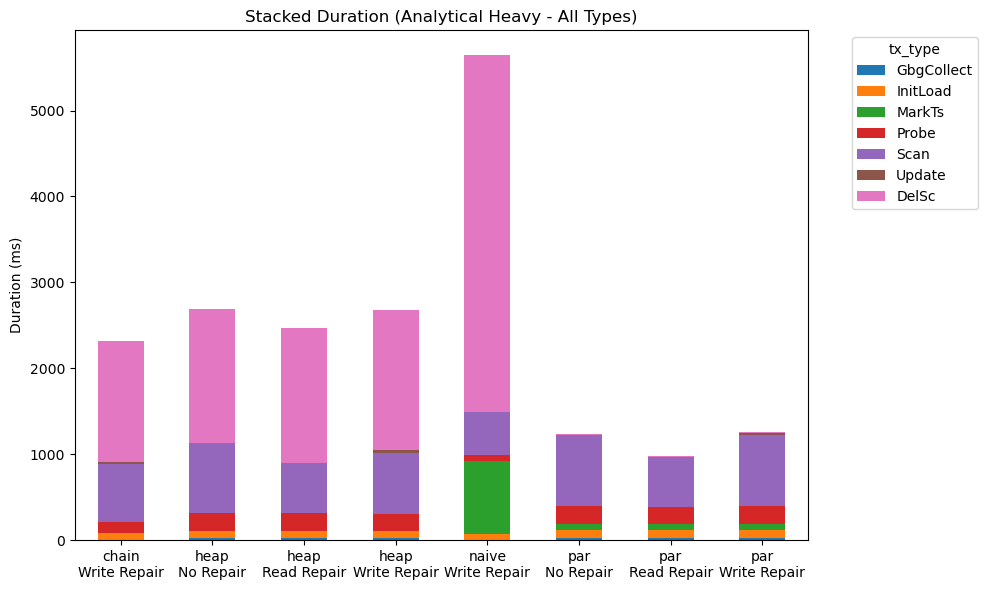

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--warehouse-count", "4" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--analytical-ratio", "0.9",
    "--scan-count", "9"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart  -- transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 3 repeats...
   - Trail 1/3
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '35', '--analytical-ratio', '0.15', '--scan-count', '2', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.15
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 2

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 5250
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 5250
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Update, Update count: 5250
idx:   6, tx_id:   6, tx_ts:   6, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count: 5250
idx: 

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,3756.398525
1,chain,Write Repair,FirstScan,674.907371
2,chain,Write Repair,GbgCollect,1.737303
3,chain,Write Repair,InitLoad,758.501524
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,2295.846508
6,chain,Write Repair,Scan,675.516384
7,chain,Write Repair,Update,2912.427223
8,heap,No Repair,DelSc,4211.924727
9,heap,No Repair,FirstScan,1163.917275


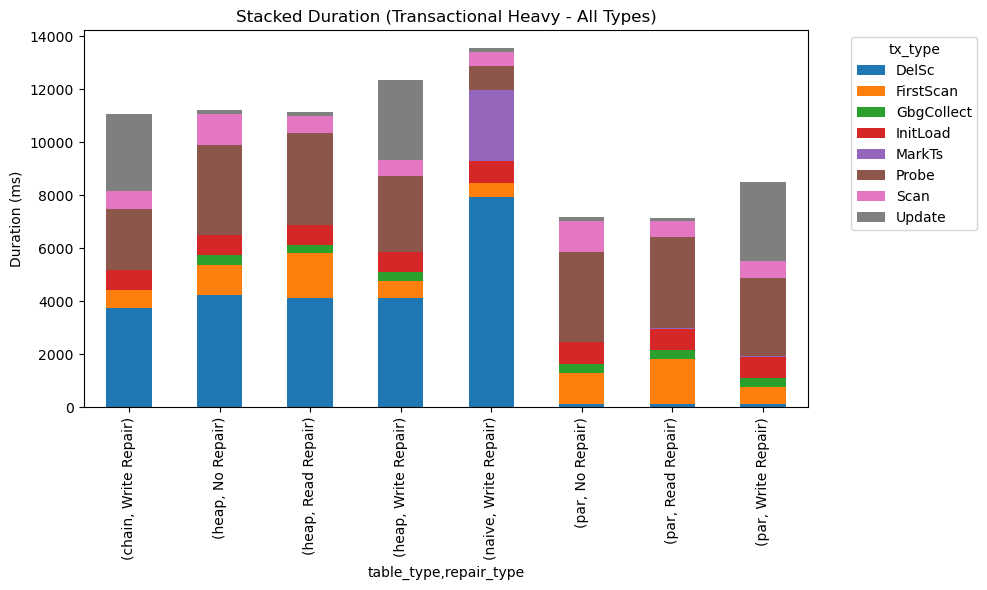

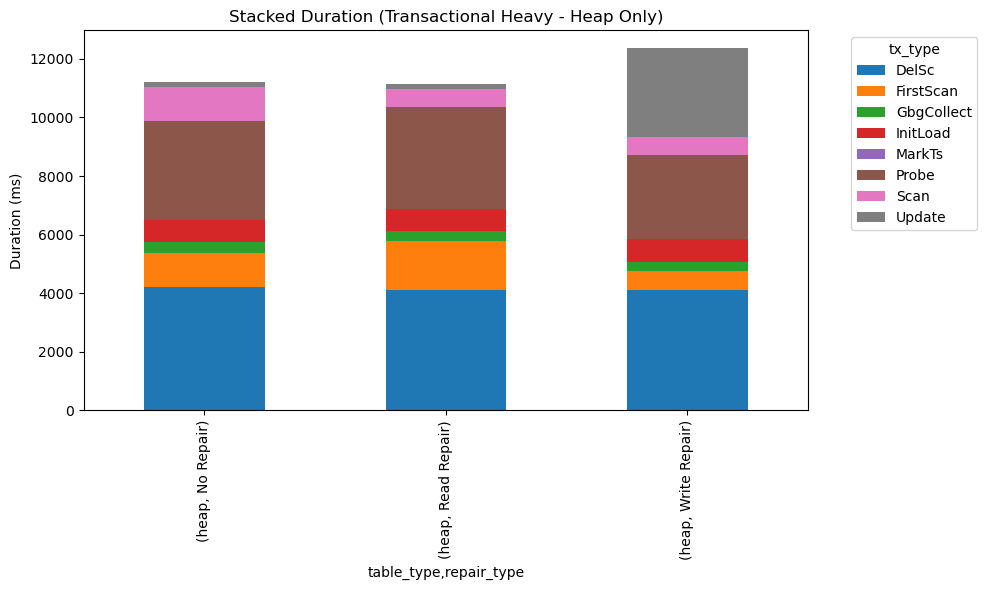

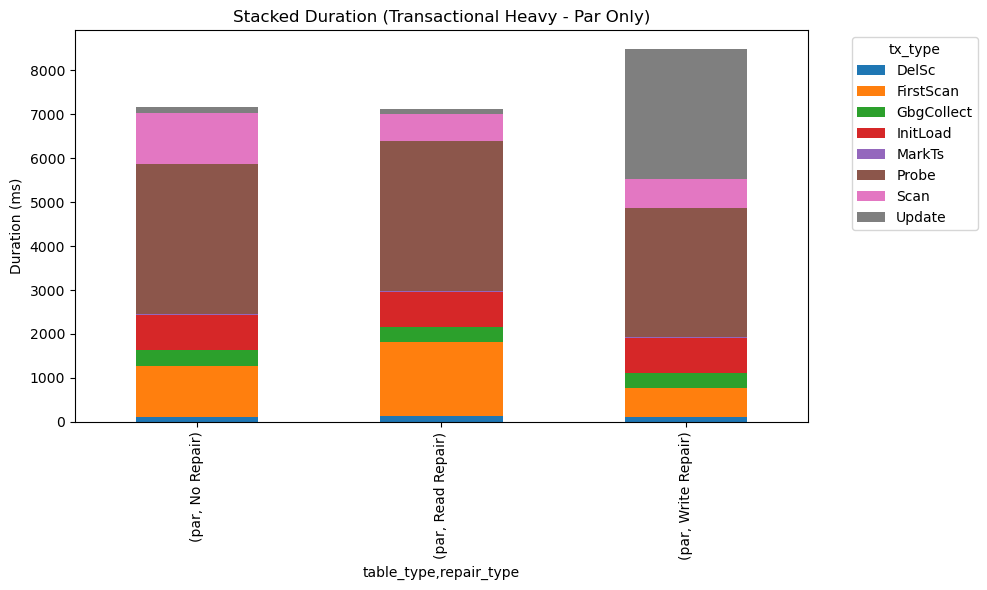

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=3
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    # def draw_stack_bar(df, classification):
    #     pivot_df = df.pivot_table(
    #         index=["table_type", "repair_type"],
    #         columns="tx_type",
    #         values="duration_ms",
    #         aggfunc="sum",
    #         fill_value=0
    #     )

    #     # stacked bar chart
    #     ax = pivot_df.plot(
    #         kind="bar",
    #         stacked=True,
    #         figsize=(10, 6)
    #     )

    #     plt.ylabel("Duration (ms)")
    #     plt.title(f"Stacked Duration ({TITLE} - {classification})")
    #     plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
    #     plt.tight_layout()
    #     plt.show()
    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--analytical-ratio", "0.15",
    "--scan-count", "2"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- Hybrid

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 3 repeats...
   - Trail 1/3
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '35', '--analytical-ratio', '0.5', '--scan-count', '5', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.5
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 5

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 5250
idx:   5, tx_id:   5, tx_ts:   5, tx_type:      Probe, Probe count: 5250 at read_ts: 1
idx:   6, tx_id:   6, tx_ts:   6, tx_type:     Update, Update count: 5250
idx:   7, tx_id:   7, tx_ts:   7, tx_type:     Update, Update count

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,11640.439549
1,chain,Write Repair,FirstScan,659.145988
2,chain,Write Repair,GbgCollect,0.885644
3,chain,Write Repair,InitLoad,759.904042
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,6256.810864
6,chain,Write Repair,Scan,2647.618390
7,chain,Write Repair,Update,1829.060796
8,heap,No Repair,DelSc,13050.553745
9,heap,No Repair,FirstScan,1081.428625


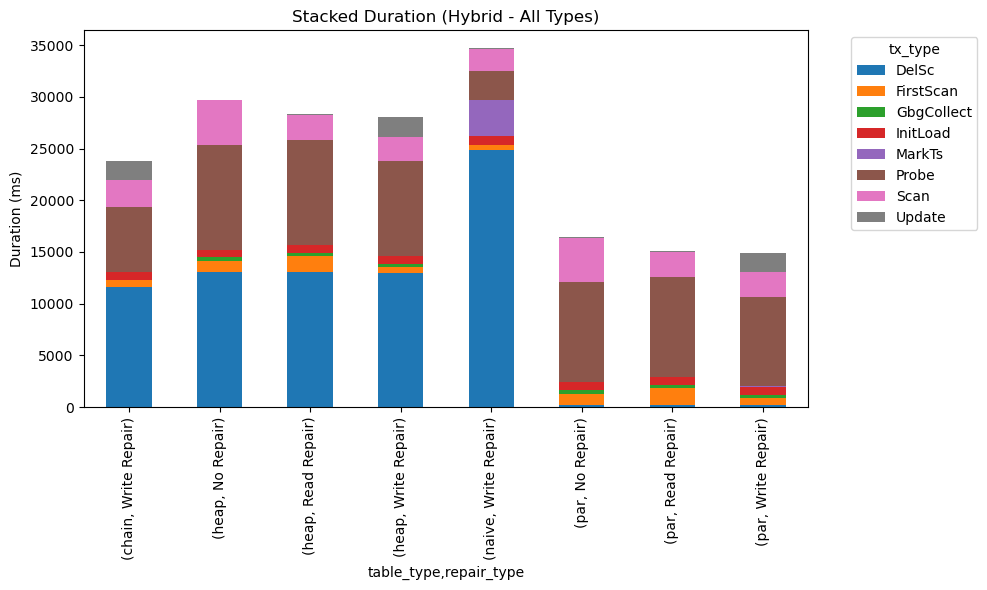

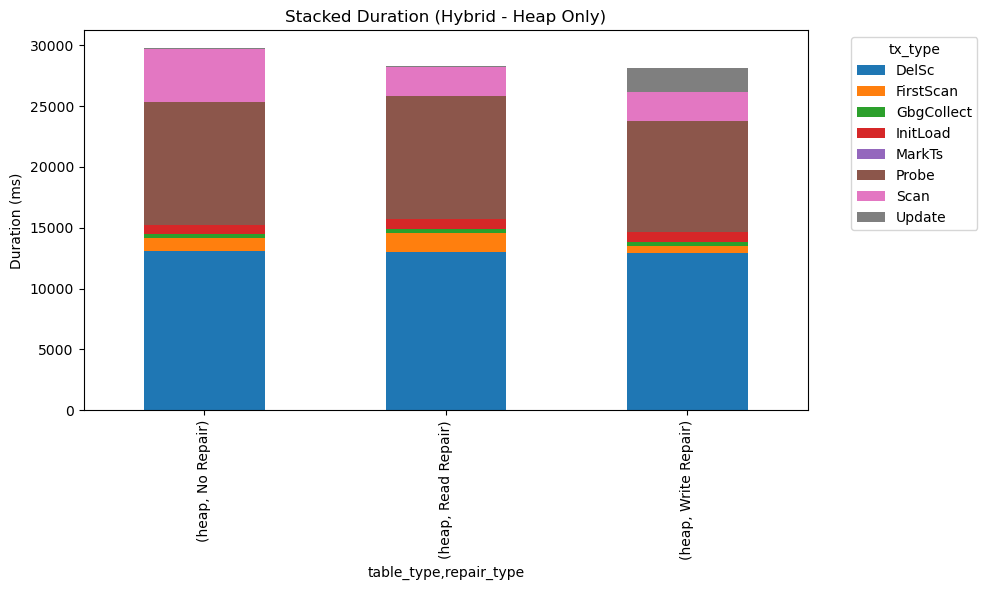

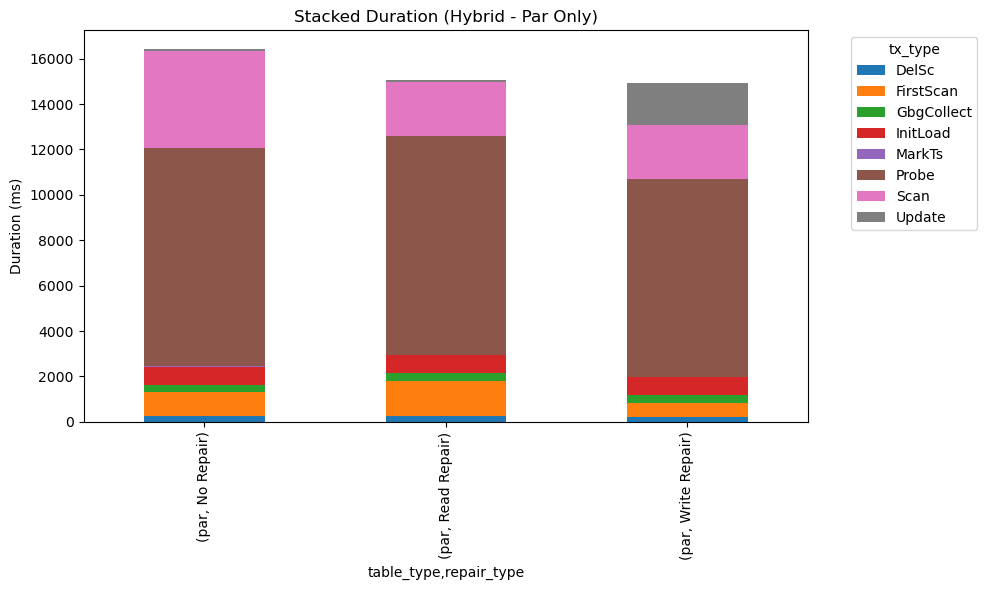

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Hybrid"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=3
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE, "All Types")

added_args = [
    "--analytical-ratio", "0.5",
    "--scan-count", "5"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# End timestamp in no_repair

In [ ]:
remove_end_ts_in_no_repair

In [8]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["heap", "par"]

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair"]
    color_map, repair_hatches, _repair_types, _table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

new_args = BASE_ARGS + ["--space-stat", "on"]

df1 = run_and_collect(BIN, TABLE_TYPES, new_args, REPEAT)

# Build with no_endtimestamp flag
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--features", "remove_end_ts_in_no_repair", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


df2 = run_and_collect(BIN, TABLE_TYPES, new_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df1)
display(df2)
plot_all(df1)
plot_all(df2)

# [Space Statistics] StatCollector { total_space: 152567808, all_versions_space: 124584000, valid_space: 107400000, header_space: 32592 }
# [Space Statistics] StatCollector { total_space: 150732800, all_versions_space: 124584000, valid_space: 107400000, header_space: 32200 }

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=heap with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '35', '--space-stat', 'on', '--table-type', 'heap']
-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 5250
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 52

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,242.881910,1050000.0,NaN,NaN,NaN
1,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
2,2,2,Update,No Repair,heap,1.954968,5250.0,NaN,NaN,NaN
3,3,3,Update,No Repair,heap,1.332776,5250.0,NaN,NaN,NaN
4,4,4,Update,No Repair,heap,1.326038,5250.0,NaN,NaN,NaN
5,5,5,Update,No Repair,heap,1.339818,5250.0,NaN,NaN,NaN
6,6,6,Probe,No Repair,heap,305.157484,5250.0,1.0,NaN,NaN
7,7,7,Update,No Repair,heap,1.553597,5250.0,NaN,NaN,NaN
8,8,8,Update,No Repair,heap,1.304589,5250.0,NaN,NaN,NaN
9,9,9,Probe,No Repair,heap,306.277759,5250.0,1.0,NaN,NaN


,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,heap,241.737463,1050000.0,NaN,NaN,NaN
1,1,1,MarkTs,No Repair,heap,0.000000,NaN,1.0,NaN,NaN
2,2,2,Update,No Repair,heap,1.150957,5250.0,NaN,NaN,NaN
3,3,3,Update,No Repair,heap,1.312280,5250.0,NaN,NaN,NaN
4,4,4,Update,No Repair,heap,1.315823,5250.0,NaN,NaN,NaN
5,5,5,Update,No Repair,heap,1.333033,5250.0,NaN,NaN,NaN
6,6,6,Probe,No Repair,heap,293.585571,5250.0,1.0,NaN,NaN
7,7,7,Update,No Repair,heap,1.341634,5250.0,NaN,NaN,NaN
8,8,8,Update,No Repair,heap,1.381344,5250.0,NaN,NaN,NaN
9,9,9,Probe,No Repair,heap,295.669393,5250.0,1.0,NaN,NaN


,table_type,repair_type,tx_type,duration_ms
0,heap,No Repair,DelSc,6273.122705
1,heap,No Repair,InitLoad,242.881910
2,heap,No Repair,MarkTs,0.000000
3,heap,No Repair,Probe,2569.516050
4,heap,No Repair,Scan,2366.570447
5,heap,No Repair,Update,37.442018
6,par,No Repair,DelSc,176.567077
7,par,No Repair,InitLoad,267.222630
8,par,No Repair,MarkTs,15.181503
9,par,No Repair,Probe,2125.725053


,table_type,repair_type,tx_type,duration_ms
0,heap,No Repair,DelSc,47.708646
1,heap,No Repair,InitLoad,241.737463
2,heap,No Repair,MarkTs,0.000000
3,heap,No Repair,Probe,2476.983201
4,heap,No Repair,Scan,2364.661954
5,heap,No Repair,Update,36.242539
6,par,No Repair,DelSc,2.764245
7,par,No Repair,InitLoad,257.303284
8,par,No Repair,MarkTs,15.129002
9,par,No Repair,Probe,2060.654750
